In [ ]:
import os
import sys

# Repository root, so that paths.py (DATA_DIR / RESULTS_DIR / FIGURES_DIR) can be imported.
sys.path.insert(0, os.path.abspath('../..'))
import paths

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

import torch

import sherlock as slk

In [2]:
import matplotlib as mpl
mpl.rcParams.update({'font.size': 12, 'svg.fonttype': 'none'})
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
figure_dir = f"{paths.FIGURES_DIR}/egfr_drug_screen/"
os.makedirs(figure_dir, exist_ok=True)

In [3]:
pert_type = 'drug_egfr'  # 'crispri' or 'crisprko'

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
slk.configs.show()
slk.configs.set_config('ntc_label', 'DMSO')
slk.configs.set_config('pert_key', 'drug')
slk.configs.show()
#slk.configs.reset_config()
slk.configs.get_config('ntc_label')


ntc_label       = NTC
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated
ntc_label       = DMSO
pert_key        = drug
treatment_key   = treatment
untreated_label = untreated


'DMSO'

In [6]:
slk.configs.get_config('ntc_label')

'DMSO'

In [7]:
concentration = 10000
data = sc.read_h5ad(f"{paths.DATA_DIR}/gbm/bt333_egfr_degs_{concentration}.h5ad")

data.obs

,P7,P5,sample,Size_Factor,n_umi,cell_ID,RT,Lig,RT_well_position,cell_line,...,top_to_second_best_ratio,log10_dose,Cell,log10_umi,percent_mito,doublet_score,num_genes_expressed,g1s_score,g2m_score,proliferation_index
0,01D,A04,1,8.052607,10718,01D_A04_RT_BC_105_Lig_BC_129,RT_BC_105,Lig_BC_129,A09,BT333,...,21.200000,2.0,01D_A04_RT_BC_105_Lig_BC_129,4.030114,0.0,0.025488,4806,1.248086,2.856022,2.989507
1,01D,A04,1,1.441776,1919,01D_A04_RT_BC_105_Lig_BC_144,RT_BC_105,Lig_BC_144,A09,BT333,...,21.285714,-inf,01D_A04_RT_BC_105_Lig_BC_144,3.283075,0.0,0.036003,1396,0.000000,1.125179,1.125179
3,01D,A04,1,1.978215,2633,01D_A04_RT_BC_105_Lig_BC_166,RT_BC_105,Lig_BC_166,A09,BT333,...,131.000000,1.0,01D_A04_RT_BC_105_Lig_BC_166,3.420451,0.0,0.023551,1784,0.000000,1.618209,1.618209
5,01D,A04,1,2.714505,3613,01D_A04_RT_BC_105_Lig_BC_31,RT_BC_105,Lig_BC_31,A09,BT333,...,56.500000,2.0,01D_A04_RT_BC_105_Lig_BC_31,3.557868,0.0,0.018055,2492,2.208781,2.358793,2.927602
7,01D,A04,1,3.605566,4799,01D_A04_RT_BC_105_Lig_BC_63,RT_BC_105,Lig_BC_63,A09,BT333,...,77.000000,3.0,01D_A04_RT_BC_105_Lig_BC_63,3.681151,0.0,0.025801,2792,1.328000,2.821908,2.974630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53205,12C,H04,2,3.250194,4326,12C_H04_RT_BC_192_Lig_BC_64,RT_BC_192,Lig_BC_64,H12,BT333,...,31.333333,3.0,12C_H04_RT_BC_192_Lig_BC_64,3.636087,0.0,0.111968,2689,0.802314,0.802314,1.241671
53206,12C,H04,2,2.090913,2783,12C_H04_RT_BC_192_Lig_BC_75,RT_BC_192,Lig_BC_75,H12,BT333,...,12.750000,4.0,12C_H04_RT_BC_192_Lig_BC_75,3.444513,0.0,0.016546,1931,1.353141,1.069197,1.754853
53207,12C,H04,2,2.929382,3899,12C_H04_RT_BC_192_Lig_BC_79,RT_BC_192,Lig_BC_79,H12,BT333,...,7.142857,4.0,12C_H04_RT_BC_192_Lig_BC_79,3.590953,0.0,0.025991,2580,2.290066,1.865924,2.730301
53208,12C,H04,2,2.873784,3825,12C_H04_RT_BC_192_Lig_BC_93,RT_BC_192,Lig_BC_93,H12,BT333,...,62.000000,1.0,12C_H04_RT_BC_192_Lig_BC_93,3.582631,0.0,0.042378,2434,0.872085,1.499563,1.770131


In [8]:
# remove na from drug column
data = data[~data.obs['drug'].isna()].copy()
data = data[
    (data.obs['dose'] == concentration) | (data.obs['drug'] == 'DMSO')
].copy()

In [9]:
# filter for drugs has more than 100 cells
drug_counts = data.obs['drug'].value_counts()
drugs_to_keep = drug_counts[drug_counts > 100].index
data = data[data.obs['drug'].isin(drugs_to_keep)].copy()

print(f"Kept {len(drugs_to_keep)} drugs with > 100 cells.")
print(data.obs['drug'].value_counts())

Kept 50 drugs with > 100 cells.
drug
DMSO                        4464
Allitinib                    354
Cyasterone                   177
AG555                        173
AG-490                       164
HER2-Inhibitor-1             162
Nazartinib                   161
EBE-A22                      160
Genistein                    156
Icotinib                     154
Varlitinib                   154
SU5214                       154
BDTX-189                     153
AG99                         153
Lidocaine                    151
CP-724714                    151
EAI045                       151
JBJ-04-125-02                150
AC480                        149
Lapatinib                    145
Norcantharidin               144
Neratinib                    143
TAS6417                      143
Lifirafenib                  143
Irbinitinib                  141
TyrphostinAG-528             140
PD153035                     137
PD168393                     137
Afatinib                     134
RG1302

In [10]:
slk.pp.slk_prepare_data(data, pert_key="drug", ntc_label="DMSO", inplace=True)

AnnData object with n_obs × n_vars = 11420 × 1157
    obs: 'P7', 'P5', 'sample', 'Size_Factor', 'n_umi', 'cell_ID', 'RT', 'Lig', 'RT_well_position', 'cell_line', 'replicate', 'drug', 'dose', 'hash_plate', 'hash_well', 'hash_umis', 'proportion', 'total_hash_umis_per_cell', 'rank', 'top_to_second_best_ratio', 'log10_dose', 'Cell', 'log10_umi', 'percent_mito', 'doublet_score', 'num_genes_expressed', 'g1s_score', 'g2m_score', 'proliferation_index', 'treatment'
    var: 'id', 'gene_short_name', 'num_cells_expressed'

In [11]:
slk.pp.treat_effect(
    data,
    label_col = "drug",
    control_label = 'DMSO',
    method = "perturbseq",
    inplace=True,
    key='treat_effect'
)

  0%|          | 0/49 [00:00<?, ?it/s]

100%|██████████| 49/49 [00:00<00:00, 883.60it/s]

In [12]:
data

AnnData object with n_obs × n_vars = 11420 × 1157
    obs: 'P7', 'P5', 'sample', 'Size_Factor', 'n_umi', 'cell_ID', 'RT', 'Lig', 'RT_well_position', 'cell_line', 'replicate', 'drug', 'dose', 'hash_plate', 'hash_well', 'hash_umis', 'proportion', 'total_hash_umis_per_cell', 'rank', 'top_to_second_best_ratio', 'log10_dose', 'Cell', 'log10_umi', 'percent_mito', 'doublet_score', 'num_genes_expressed', 'g1s_score', 'g2m_score', 'proliferation_index', 'treatment'
    var: 'id', 'gene_short_name', 'num_cells_expressed'
    uns: 'treat_effect'

In [13]:
data.X.max()

1142.0

In [14]:
# Check for NaN/Inf in expression matrix
print(f"Data shape: {data.shape}")
X = data.X.toarray() if hasattr(data.X, 'toarray') else data.X

n_nan = np.isnan(X).sum()
n_inf = np.isinf(X).sum()
print(f"NaN values in X: {n_nan}")
print(f"Inf values in X: {n_inf}")

if n_nan > 0 or n_inf > 0:
    print("Cleaning expression matrix...")
    # Replace NaN with 0 and clip Inf values
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    data.X = X
    print("Expression matrix cleaned!")

# Check data stats
print(f"X min: {data.X.min()}, max: {data.X.max()}")
print(f"Unique drugs: {data.obs['drug'].nunique()}")

Data shape: (11420, 1157)
NaN values in X: 0
Inf values in X: 0
X min: 0.0, max: 1142.0
Unique drugs: 50


In [15]:
data.obs

,P7,P5,sample,Size_Factor,n_umi,cell_ID,RT,Lig,RT_well_position,cell_line,...,log10_dose,Cell,log10_umi,percent_mito,doublet_score,num_genes_expressed,g1s_score,g2m_score,proliferation_index,treatment
1,01D,A04,1,1.441776,1919,01D_A04_RT_BC_105_Lig_BC_144,RT_BC_105,Lig_BC_144,A09,BT333,...,-inf,01D_A04_RT_BC_105_Lig_BC_144,3.283075,0.0,0.036003,1396,0.000000,1.125179,1.125179,untreated
10,01D,A04,1,0.664915,885,01D_A04_RT_BC_106_Lig_BC_177,RT_BC_106,Lig_BC_177,A10,BT333,...,-inf,01D_A04_RT_BC_106_Lig_BC_177,2.946943,0.0,0.028294,737,0.917870,0.917870,1.388268,untreated
19,01D,A04,1,2.364392,3147,01D_A04_RT_BC_107_Lig_BC_3,RT_BC_107,Lig_BC_3,A11,BT333,...,4.0,01D_A04_RT_BC_107_Lig_BC_3,3.497897,0.0,0.014757,2208,1.654300,2.102915,2.519262,untreated
22,01D,A04,1,1.484601,1976,01D_A04_RT_BC_107_Lig_BC_92,RT_BC_107,Lig_BC_92,A11,BT333,...,4.0,01D_A04_RT_BC_107_Lig_BC_92,3.295787,0.0,0.022303,1508,1.105504,1.105504,1.617702,untreated
23,01D,A04,1,2.138246,2846,01D_A04_RT_BC_107_Lig_BC_98,RT_BC_107,Lig_BC_98,A11,BT333,...,4.0,01D_A04_RT_BC_107_Lig_BC_98,3.454235,0.0,0.008150,1906,0.000000,0.660286,0.660286,untreated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53176,12C,H04,2,10.582288,14085,12C_H04_RT_BC_179_Lig_BC_190,RT_BC_179,Lig_BC_190,G11,BT333,...,4.0,12C_H04_RT_BC_179_Lig_BC_190,4.148757,0.0,0.057617,5983,2.200806,1.658683,2.586611,untreated
53179,12C,H04,2,6.912860,9201,12C_H04_RT_BC_179_Lig_BC_38,RT_BC_179,Lig_BC_38,G11,BT333,...,-inf,12C_H04_RT_BC_179_Lig_BC_38,3.963835,0.0,0.030208,4675,0.254112,0.544235,0.699430,untreated
53195,12C,H04,2,1.160032,1544,12C_H04_RT_BC_191_Lig_BC_159,RT_BC_191,Lig_BC_159,H11,BT333,...,4.0,12C_H04_RT_BC_191_Lig_BC_159,3.188647,0.0,0.035640,1255,1.277075,1.820067,2.170014,untreated
53206,12C,H04,2,2.090913,2783,12C_H04_RT_BC_192_Lig_BC_75,RT_BC_192,Lig_BC_75,H12,BT333,...,4.0,12C_H04_RT_BC_192_Lig_BC_75,3.444513,0.0,0.016546,1931,1.353141,1.069197,1.754853,untreated


In [16]:
data

AnnData object with n_obs × n_vars = 11420 × 1157
    obs: 'P7', 'P5', 'sample', 'Size_Factor', 'n_umi', 'cell_ID', 'RT', 'Lig', 'RT_well_position', 'cell_line', 'replicate', 'drug', 'dose', 'hash_plate', 'hash_well', 'hash_umis', 'proportion', 'total_hash_umis_per_cell', 'rank', 'top_to_second_best_ratio', 'log10_dose', 'Cell', 'log10_umi', 'percent_mito', 'doublet_score', 'num_genes_expressed', 'g1s_score', 'g2m_score', 'proliferation_index', 'treatment'
    var: 'id', 'gene_short_name', 'num_cells_expressed'
    uns: 'treat_effect'

In [17]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# results = slk.tl.run_single(data, 
#                             batch_size=1024,
#                             num_workers=0, 
#                             device=device, 
#                             use_conditions=False,
#                             l0_lambda = 10,
#                             num_epochs=1000,
#                             #gate_init_p=0.4,
#                             H_lambda=0.01,
#                             ce_lambda=0.1,
#                             latent_dim= 8,
#                             )

In [18]:
# import datetime
    
# timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# slk.tl.save_results(results, f'{paths.RESULTS_DIR}/models/{pert_type}_model_{timestamp}.pth')

In [19]:
NUM_EPOCHS     = 1000
VALIDATE_EVERY = 50
BATCH_SIZE     = 4096
LATENT_DIM     = 16
PATIENCE       = 350

In [20]:
SHERLOCK_KWARGS = {
    # "tau_end": 0.3,
    # # "tau_init": 1.5,
    # "cov_lambda": 1e-5,
    # "H_lambda": 1e-1,
    # "gate_row_repulsion_lambda": 1e-2,
    # "ce_lambda": 10,
    # "shift": "linear",
    "l0_lambda":50,
    "debug": True,
    # "lr": 1e-3,
    # "ntc_lambda": 1e-5,       
    # "pert_lambda": 1,
    "n_epochs_l0_warmup": 100
}

In [21]:
seed = 1

In [22]:
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# results = slk.tl.run(
#         data,
#         model="vae",
#         batch_size=BATCH_SIZE,
#         num_epochs=NUM_EPOCHS,
#         device=DEVICE,
#         latent_dim=LATENT_DIM,
#         patience=PATIENCE,
#         validate_every=VALIDATE_EVERY,
#         seed=seed,
#         # debug=True,
#         **SHERLOCK_KWARGS,
#     )

In [23]:
# results

In [24]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# results = slk.tl.run_single(data, batch_size=4096, shuffle=True, num_workers=9, device=device)


In [25]:
# slk.tl.save_results(results, f'{paths.RESULTS_DIR}/models/replogle_model.pth')


In [26]:
# import datetime
    
# timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# slk.tl.save_results(results, f'{paths.RESULTS_DIR}/models/{pert_type}_model_{timestamp}_{seed}.pth')

# print(f'Saved results to ../data/{pert_type}_model_{timestamp}_{seed}.pth')

In [27]:
# model = results['model']

In [28]:
# This run Ross Saved results to ../data/drug_egfr_model_20260529_163520_1.pth

In [29]:
# # this is a great run
# #model = slk.tl.load_results(f'{paths.RESULTS_DIR}/models/crispri_model_20251105_103826.pth')
# # {paths.RESULTS_DIR}/models/crispri_model_20251110_215304.pth
# #{paths.RESULTS_DIR}/models/crispri_model_20251111_004834.pth


# # accuray is not 100%
model = slk.tl.load_results(f'{paths.RESULTS_DIR}/models/drug_egfr_model_20260529_163520_1.pth')
# #model = results['model']

In [30]:
slk.tl.eval_single(model, data, obsm_key="z", uns_key="results")

In [31]:
data.uns['results']

{'z_corr': array([[ 1.        ,  0.35844737, -0.6964996 , ..., -0.00785798,
          0.7955782 ,  0.62624913],
        [ 0.35844737,  1.        , -0.7154994 , ..., -0.558457  ,
          0.5033348 ,  0.53443074],
        [-0.6964996 , -0.7154994 ,  1.        , ...,  0.2604795 ,
         -0.7529469 , -0.7199189 ],
        ...,
        [-0.00785798, -0.558457  ,  0.2604795 , ...,  1.        ,
          0.18043469, -0.32437053],
        [ 0.7955781 ,  0.5033348 , -0.752947  , ...,  0.18043469,
          1.        ,  0.32453465],
        [ 0.6262492 ,  0.5344307 , -0.71991897, ..., -0.32437056,
          0.32453465,  1.        ]], dtype=float32),
 'z_perts': array(['AC480', 'AG-1557', 'AG-18', 'AG-490', 'AG494', 'AG555', 'AG99',
        'Afatinib', 'Allitinib', 'Avitinib', 'BDTX-189', 'Butein',
        'CP-724714', 'CUDC-101', 'ChrysophanicAcid', 'Cyasterone',
        'DZD9008', 'Dacomitinib', 'Daphnetin', 'EAI045', 'EBE-A22',
        'Epigallocatechin-Gallate', 'Gefitinib', 'Genistein',


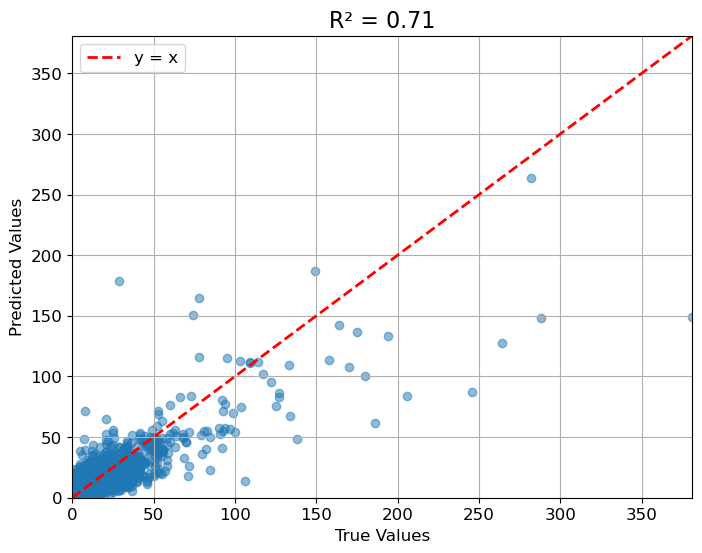

In [32]:
data.X = data.X.toarray()
slk.pl.plot_r2(data)

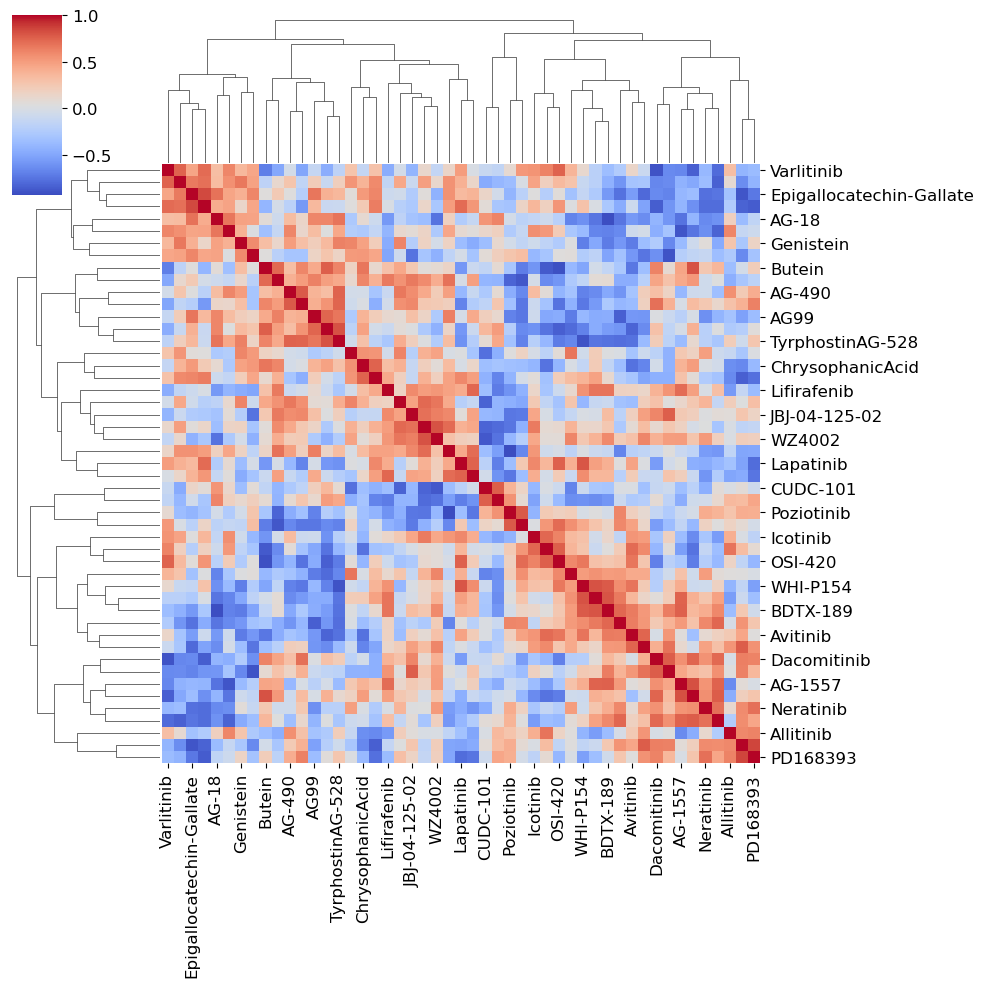

In [33]:
slk.pl.plot_corr(data)

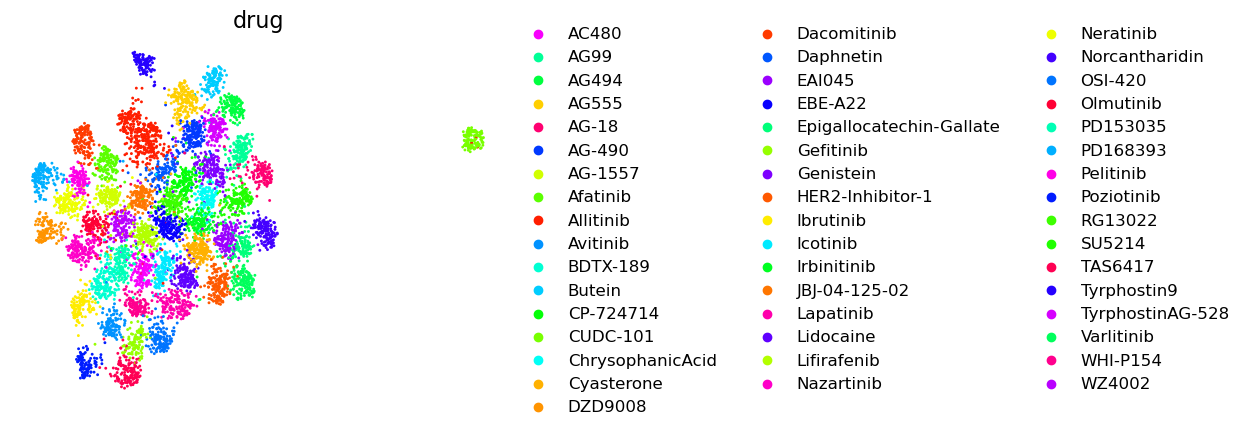

In [34]:
p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='drug', palette=palette, frameon=False)

In [35]:
zrc = data.uns['results']['z_rho_corr']

print(f"Spearman ρ = {zrc['spearman_r']:.3f}  (p = {zrc['spearman_p']:.1e})")
print(f" Pearson  r = {zrc['pearson_r']:.3f}  (p = {zrc['pearson_p']:.1e})") 

Spearman ρ = 0.948  (p = 0.0e+00)
 Pearson  r = 0.949  (p = 0.0e+00)


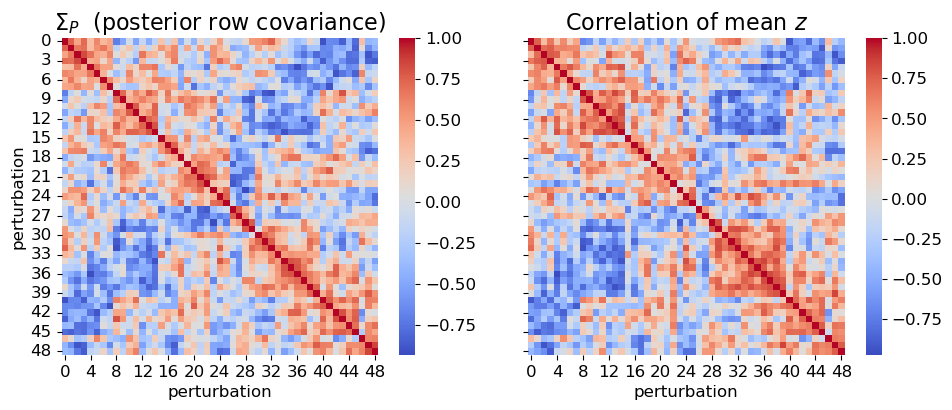

In [36]:
slk.pl.plot_zcorr(data)

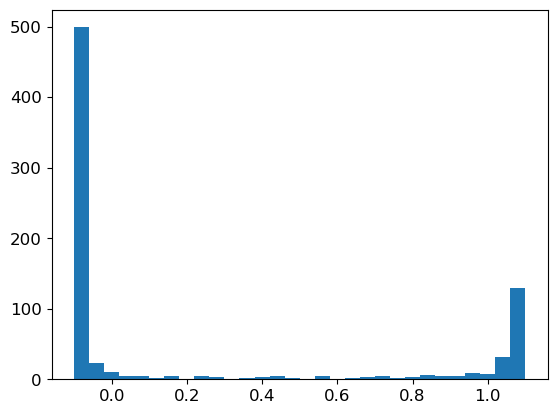

In [37]:
W = data.uns['results']['W']
plt.hist(W.flatten(), bins=30)
plt.show()

<Axes: >

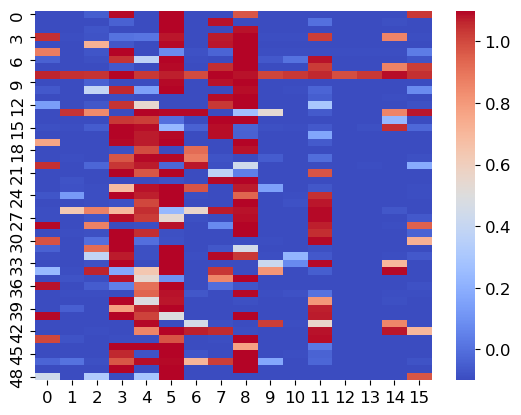

In [38]:
W_bin = (W > 0.5).astype(float)
sns.heatmap(W, cmap="coolwarm")

In [39]:

dataset = slk.tl.PerturbMatchingDataset(data)
all_genes = dataset.perturbation_dict.keys()

In [40]:

dataset = slk.tl.PerturbMatchingDataset(data)
all_genes = dataset.perturbation_dict.keys()

In [41]:
new_colormap = [
    'darkslateblue',  # 0
    'firebrick',      # 1
    'darkorange',     # 2
    'forestgreen',    # 3
    'gold',           # 4
    'dodgerblue',     # 5
    'mediumorchid',   # 6
    'deeppink',       # 7
    'teal',           # 8
    'black'           # 9
]
t = 2.2

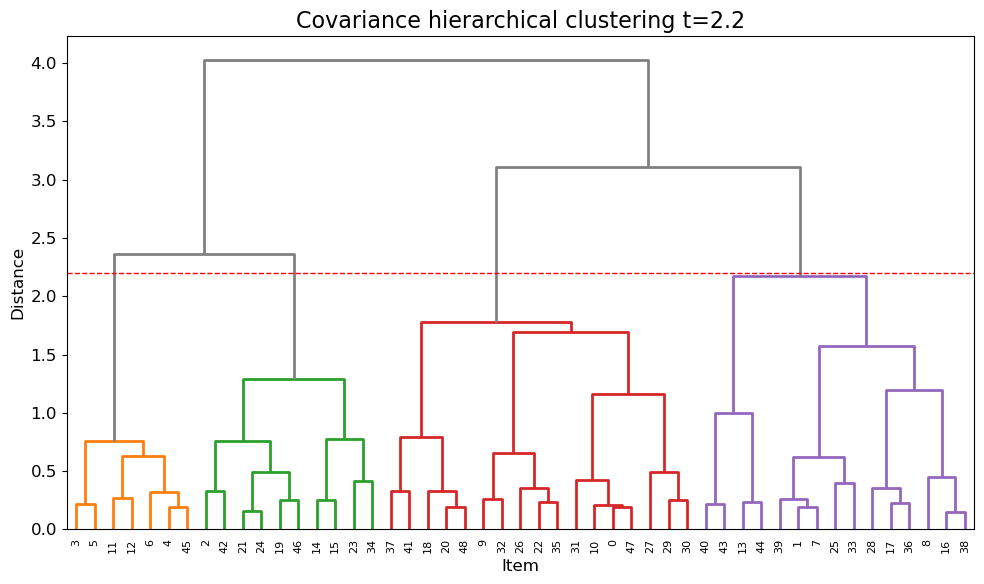

In [42]:
# 1.5 previously
groups = slk.tl.cluster_rho(data, t=t
                            , show=True)

In [43]:
#for a non subsetted data, pass in genes corresponding to idx ie dataset.perturbation_dict.keys()
named_groups = slk.tl.group2name(groups, all_genes)
named_groups

,group
AC480,3
AG-1557,4
AG-18,2
AG-490,1
AG494,1
AG555,1
AG99,1
Afatinib,4
Allitinib,4
Avitinib,3


In [44]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, set_link_color_palette
from matplotlib.colors import to_hex

def cluster_rho(adata, t=1.5, uns_key='results', rho_corr=None, show=True, pert_key='perturbation', figure_dir=None, save_name=None):
    if rho_corr is None:
        C = adata.uns[uns_key]['rho_corr']
    else:
        C = rho_corr
    
    # Get perturbation names - try multiple possible locations
    uns = adata.uns.get(uns_key, {})
    if 'rho_perts' in uns:
        pert_names = np.asarray(uns['rho_perts'])
    elif 'pert_names' in uns:
        pert_names = np.asarray(uns['pert_names'])
    elif 'perts' in uns:
        pert_names = np.asarray(uns['perts'])
    else:
        # Fall back to unique perturbation values from obs
        _pk = slk.configs.get_config('pert_key')
        ntc = slk.configs.get_config('ntc_label')
        pert_names = np.asarray([p for p in adata.obs[_pk].unique() if p != ntc])
    
    D = 1.0 - C  # distance
    Z_link = linkage(D[np.triu_indices_from(D, 1)], method='ward')
    
    # Cluster labels at this cut, and the exact colors scipy will draw for them —
    # so plot_zcorr_colored (same linkage, same t, same palette) matches this dendrogram
    groups = fcluster(Z_link, t=t, criterion='distance')
    unique_groups = sorted(set(groups))
    palette_hex = [to_hex(new_colormap[i % len(new_colormap)]) for i in range(len(unique_groups))]
    set_link_color_palette(palette_hex)
    
    if show:
        plt.figure(figsize=(max(5, len(pert_names) * 0.15), 4))
        dendrogram(
            Z_link,
            color_threshold=t,
            above_threshold_color="gray",
            labels=pert_names,  # Use actual names
            leaf_rotation=90,
            leaf_font_size=8,
        )
        plt.axhline(y=t, color="red", linestyle="--", linewidth=1)
        #plt.title(f"Covariance hierarchical clustering t={t}")
        plt.xlabel("Perturbation")
        plt.ylabel("Distance")
        plt.tight_layout()
        
        # Export the figures
        if figure_dir and save_name:
            plt.savefig(os.path.join(figure_dir, f"{save_name}_dendrogram.svg"), dpi=300, bbox_inches='tight')
            plt.savefig(os.path.join(figure_dir, f"{save_name}_dendrogram.png"), dpi=300, bbox_inches='tight')
            plt.savefig(os.path.join(figure_dir, f"{save_name}_dendrogram.pdf"), dpi=300, bbox_inches='tight')
            print(f"Saved figures to {figure_dir}/{save_name}_dendrogram.[svg|png|pdf]")
        
        plt.show()
    
    # Record the group -> color mapping scipy actually used, for reference/reuse
    ddata = dendrogram(Z_link, color_threshold=t, above_threshold_color='gray', no_plot=True)
    group_to_color = {}
    for leaf_idx, color in zip(ddata['leaves'], ddata.get('leaves_color_list', [])):
        g = groups[leaf_idx]
        if g not in group_to_color:
            group_to_color[g] = color
    adata.uns['_dendrogram_colors'] = {str(k): v for k, v in group_to_color.items()}
    
    # Return as a dictionary mapping perturbation names to cluster IDs
    cluster_assignments = dict(zip(pert_names, groups))
    
    return groups, cluster_assignments

Saved figures to /home/user/Documents/Githubs/PerturbVAE/sherlock/results/figures//drug_egfr_10000uM_dendrogram.[svg|png|pdf]


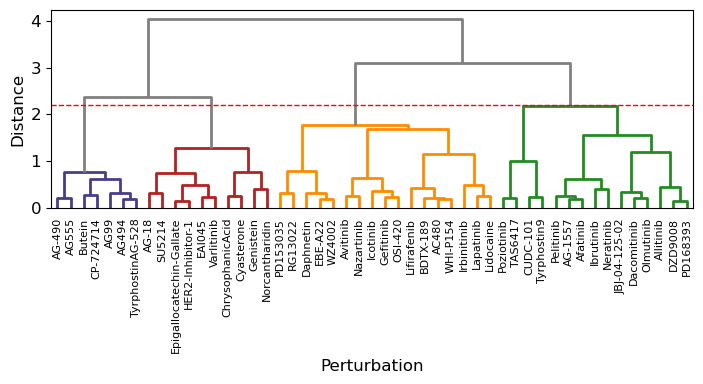

In [45]:
groups = cluster_rho(data, t=t, show=True, figure_dir=figure_dir, save_name=f"{pert_type}_{concentration}uM")

In [46]:
#named_groups.to_csv(f'{paths.RESULTS_DIR}/gbm/{pert_type}_drug_groups_{concentration}uM_final.csv')

pert_group
1    1028
2    1459
3    2338
4    2131
Name: count, dtype: int64


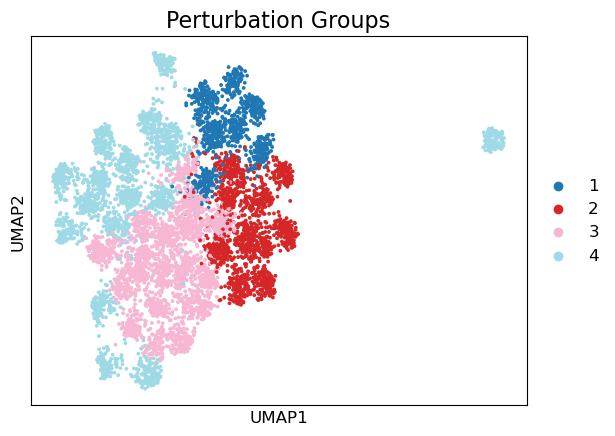

In [47]:
# map perturbation -> group using named_groups (index=gene, column='group')
gene_to_group = named_groups['group'].to_dict()

# assign group to obs based on slk pert key
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group)

# mark NTC / unknown perturbations as -1 and ensure integer dtype
sub.obs['pert_group'] = sub.obs['pert_group'].fillna(-1).astype('category')

# quick summary
print(sub.obs['pert_group'].value_counts().sort_index())

sc.pl.umap(sub, color=['pert_group'], title='Perturbation Groups', palette='tab20', size=30)

In [48]:
new_colormap = [
    'darkslateblue',  # 0
    'firebrick',      # 1
    'darkorange',     # 2
    'forestgreen',    # 3
    'gold',           # 4
    'dodgerblue',     # 5
    'mediumorchid',   # 6
    'deeppink',       # 7
    'teal',           # 8
    'black'           # 9
]

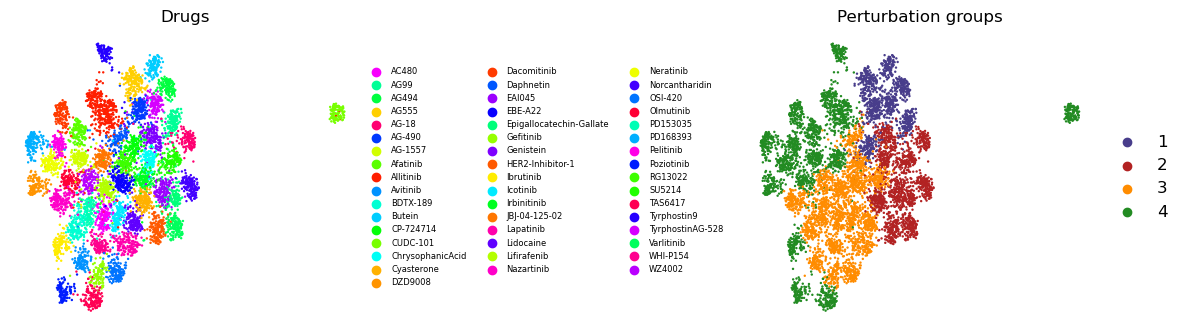

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

sc.pl.umap(
    sub,
    color='drug',
    title='Drugs',
    palette=palette,
    size=12,
    frameon=False,
    ax=axes[0],
    show=False,
    legend_fontsize=6,
)

sc.pl.umap(sub, color='pert_group', title='Perturbation groups', 
           palette=new_colormap, size=12, frameon=False, ax=axes[1], show=False)

for ax in axes:
    ax.set_title(ax.get_title(), fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(figure_dir, f"{pert_type}_{concentration}_sherlock_zspace.svg"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{pert_type}_{concentration}_sherlock_zspace.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{pert_type}_{concentration}_sherlock_zspace.pdf"), dpi=300, bbox_inches='tight')
plt.show()

In [50]:
# assign group to obs based on slk pert key
data.obs['pert_group'] = data.obs[p_key].map(gene_to_group)

# mark NTC / unknown perturbations as -1 and ensure integer dtype
data.obs['pert_group'] = data.obs['pert_group'].fillna(-1).astype('category')

# quick summary
print(data.obs['pert_group'].value_counts().sort_index())

pert_group
-1.0    4464
 1.0    1028
 2.0    1459
 3.0    2338
 4.0    2131
Name: count, dtype: int64


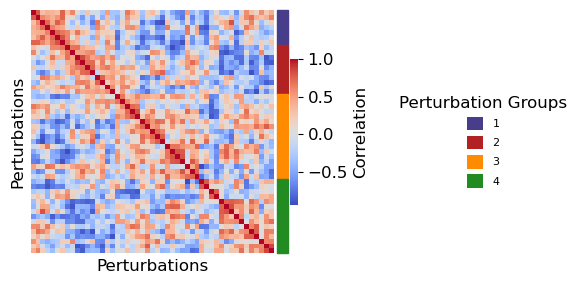

In [51]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster, dendrogram, set_link_color_palette
from matplotlib.colors import to_hex
from matplotlib import gridspec
from matplotlib.patches import Patch


def plot_zcorr_colored(adata, t=1.5, uns_key='results', group_color=new_colormap):
    """
    Plot correlation matrices with a color bar for each perturbation group.
    Uses the same linkage/threshold/palette as cluster_rho, so the bar colors
    match what cluster_rho's dendrogram draws for the same cut t.
    """
    
    Sigma_P_posterior = adata.uns[uns_key]['rho_corr']
    Sigma_z = adata.uns[uns_key]['z_corr']
    pert_names = adata.uns[uns_key]['rho_perts']

    # Same distance + linkage as cluster_rho
    D = 1.0 - Sigma_P_posterior
    Z_link = linkage(D[np.triu_indices_from(D, 1)], method='ward')
    order = leaves_list(Z_link)

    # Apply the same permutation to both matrices
    SigmaP_ord = Sigma_P_posterior[order][:, order]
    Sigmaz_ord = Sigma_z[order][:, order]
    pert_names_ord = pert_names[order]

    # Same cut as cluster_rho(..., t=t)
    groups = fcluster(Z_link, t=t, criterion='distance')
    groups_ord = groups[order]
    unique_groups = sorted(set(groups))

    # Same palette + same scipy color-assignment logic as cluster_rho, so colors match the dendrogram
    palette_hex = [to_hex(group_color[i % len(group_color)]) for i in range(len(unique_groups))]
    set_link_color_palette(palette_hex)
    ddata = dendrogram(Z_link, color_threshold=t, above_threshold_color='gray', no_plot=True)
    group_to_color = {}
    for leaf_idx, color in zip(ddata['leaves'], ddata.get('leaves_color_list', [])):
        g = groups[leaf_idx]
        if g not in group_to_color:
            group_to_color[g] = color

    row_colors = [group_to_color[grp] for grp in groups_ord]
    n_perts = len(pert_names_ord)

    # Bar width and its gap from the heatmap, scaled to stay proportional to heatmap
    # size (reference notebook used width=3, gap=1 for 71 perturbations)
    side_bar_width = n_perts * (3 / 71)
    bar_gap = n_perts * (1 / 71)

    # Plot single heatmap
    fig = plt.figure(figsize=(4, 3))
    ax0 = fig.add_subplot(111)
    
    sns.heatmap(SigmaP_ord, cmap="coolwarm", square=True, ax=ax0, 
                xticklabels=False,
                yticklabels=False,
                cbar_kws={
                    'label': 'Correlation',
                    'shrink': 0.6,
                    'aspect': 20
                })
    ax0.set_title("")
    ax0.set_xlabel("Perturbations")
    ax0.set_ylabel("Perturbations")
    
    # Add vertical color bar on the right, with a small gap from the heatmap
    for i, color in enumerate(row_colors):
        ax0.add_patch(plt.Rectangle((n_perts + bar_gap, i), side_bar_width, 1, color=color, 
                                    transform=ax0.transData, clip_on=False))

    # Create legend outside with transparent background
    legend_elements = [Patch(facecolor=group_to_color[grp], label=f'{int(grp)}')
                      for grp in unique_groups]
    fig.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1.0, 0.5),
        title='Perturbation Groups',
        fontsize=8,
        handlelength=1.5,
        handleheight=1.5,
        frameon=False
    )

    plt.tight_layout()
    plt.savefig(os.path.join(figure_dir, f"{pert_type}_correlation_color.svg"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(figure_dir, f"{pert_type}_correlation_color.png"), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(figure_dir, f"{pert_type}_correlation_color.pdf"), dpi=300, bbox_inches='tight')
    plt.show()

plot_zcorr_colored(data, t=t)

In [52]:
# Load drug annotation CSV
drug_anno = pd.read_csv(f'{paths.DATA_DIR}/gbm/EGFRi_annotations_final_RG.csv')

# The h5ad 'drug' column uses short names matching the CSV 'drug' column
# Try matching on short name first; fall back to full 'name' if needed
anno_cols = ['class_broad', 'reversible', 'specificity_RG', 'target_amino_acid_or_binding_site'	]

drug_meta_short = drug_anno.set_index('drug')[anno_cols]
drug_meta_full  = drug_anno.set_index('name')[anno_cols]

obs_drugs = sub.obs['drug'].unique()
n_short = sum(d in drug_meta_short.index for d in obs_drugs)
n_full  = sum(d in drug_meta_full.index  for d in obs_drugs)
print(f"Short-name matches: {n_short}/{len(obs_drugs)}")
print(f"Full-name  matches: {n_full}/{len(obs_drugs)}")

drug_meta = drug_meta_short if n_short >= n_full else drug_meta_full

for col in anno_cols:
    sub.obs[col] = sub.obs['drug'].map(drug_meta[col])
    # fill missing with 'Unknown' so scanpy treats it as a proper category
    sub.obs[col] = sub.obs[col].fillna('Unknown').astype('category')

print("\nAnnotation columns added to sub.obs:")
for col in anno_cols:
    n_unknown = (sub.obs[col] == 'Unknown').sum()
    print(f"  {col}: {sub.obs[col].nunique()} categories, {n_unknown} unmatched cells")

sub.obs[['drug'] + anno_cols].drop_duplicates('drug').sort_values('drug')


Short-name matches: 48/49
Full-name  matches: 25/49

Annotation columns added to sub.obs:
  class_broad: 14 categories, 132 unmatched cells
  reversible: 3 categories, 1067 unmatched cells
  specificity_RG: 17 categories, 3322 unmatched cells
  target_amino_acid_or_binding_site: 11 categories, 1983 unmatched cells


,drug,class_broad,reversible,specificity_RG,target_amino_acid_or_binding_site
236,AC480,indole,Yes,HER2_HER3_HER4,ATP
58,AG99,tyrphostin,Yes,Unknown,Unknown
1151,AG494,tyrphostin,Yes,Unknown,ATP
45,AG555,tyrphostin,Yes,Unknown,topoisomerase I
1777,AG-18,tyrphostin,Yes,Unknown,Unknown
378,AG-490,tyrphostin,Yes,JAK,Unknown
306,AG-1557,tyrphostin,Yes,Unknown,Unknown
223,Afatinib,quinazoline,No,HER2_HER4,cys-res
19,Allitinib,quinazoline,No,Unknown,cys797_cys805
1098,Avitinib,pyrimidine,No,Unknown,cys797


In [53]:
for col in ['class_broad', 'reversible']:
    if hasattr(sub.obs[col], 'cat'):
        sub.obs[col] = sub.obs[col].cat.rename_categories({'Unknown': 'Unannotated'})
    else:
        sub.obs[col] = sub.obs[col].replace('Unknown', 'Unannotated')
        
    if col == 'reversible':
        if hasattr(sub.obs[col], 'cat'):
            sub.obs[col] = sub.obs[col].cat.rename_categories({
                'Yes': 'Reversible',
                'No': 'Covalent',
            })

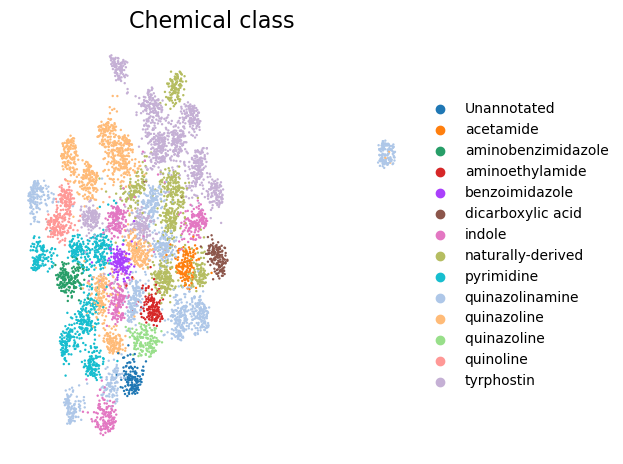

In [54]:
sc.pl.umap(
    sub,
    color='class_broad',
    title='Chemical class',
    size=12,
    frameon=False,
    show=False,
    legend_fontsize=10
)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir,'umap_pert_class_broad.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir,'umap_pert_class_broad.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir,'umap_pert_class_broad.svg'), dpi=300, bbox_inches='tight')
plt.show()

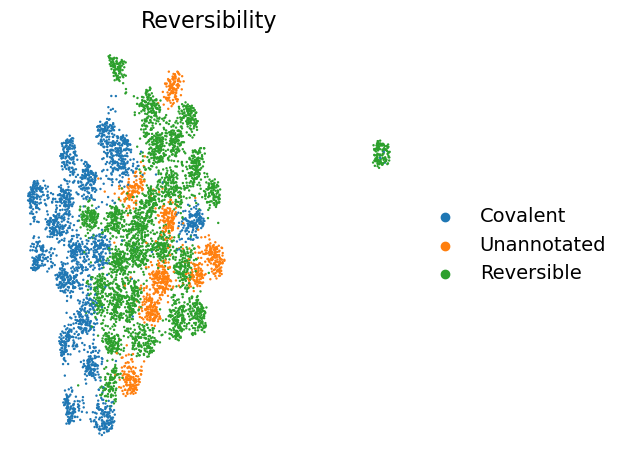

In [55]:
sc.pl.umap(
    sub,
    color='reversible',
    title='Reversibility',
    size=12,
    frameon=False,
    show=False,
    legend_fontsize=14
)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir,'umap_pert_reversible.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir,'umap_pert_reversible.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir,'umap_pert_reversible.svg'), dpi=300, bbox_inches='tight')
plt.show()

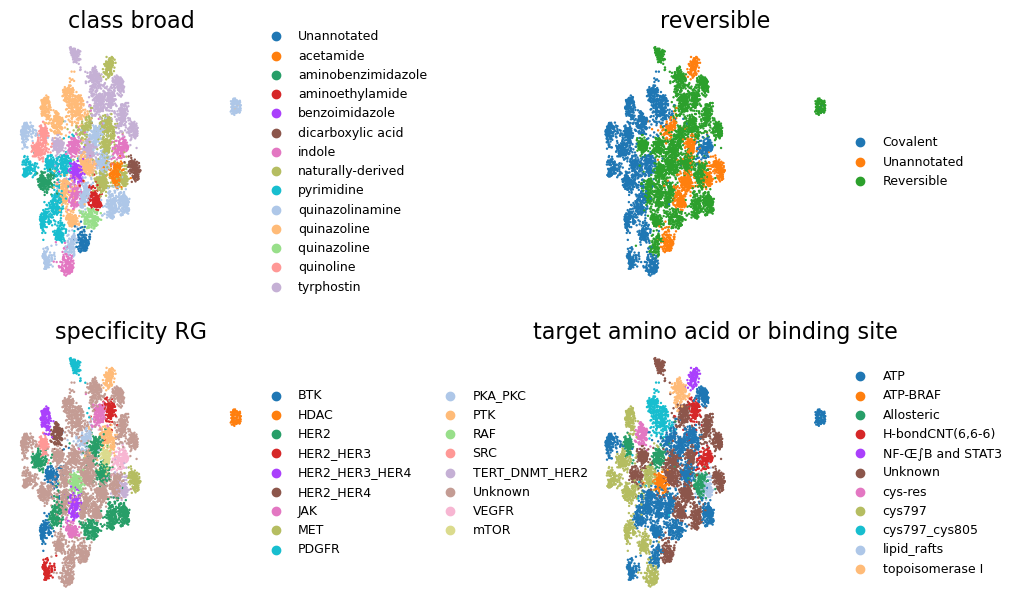

In [56]:
# Plot UMAP coloured by each drug-annotation column
import math
ncols = 2
nrows = math.ceil(len(anno_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, anno_cols):
    sc.pl.umap(
        sub,
        color=col,
        title=col.replace('_', ' '),
        frameon=False,
        ax=ax,
        show=False,
        size=12,
        legend_fontsize=9,
    )

# hide unused axes
for ax in axes[len(anno_cols):]:
    ax.set_visible(False)

plt.tight_layout(pad=0.1)
for ext in ('svg', 'png', 'pdf'):
    plt.savefig(
        os.path.join(figure_dir, f'{pert_type}_{concentration}_drug_annotations.{ext}'),
        dpi=300, bbox_inches='tight'
    )
plt.show()


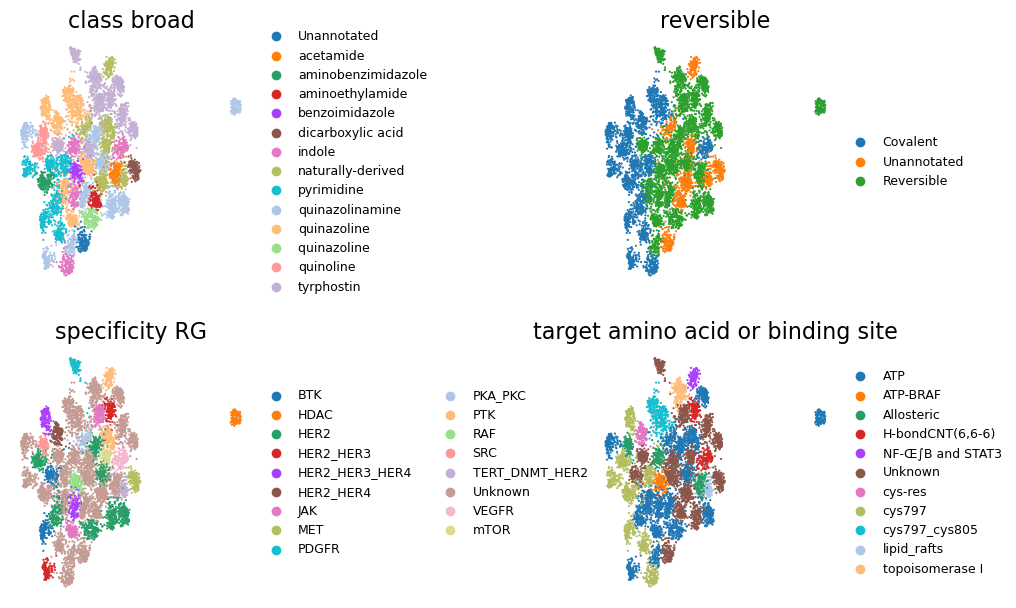

In [57]:
# Overview: key grouping columns side-by-side
overview_cols = ['class_broad', 'reversible', 'specificity_RG', 'target_amino_acid_or_binding_site']

ncols = 2
nrows = math.ceil(len(overview_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, overview_cols):
    sc.pl.umap(
        sub,
        color=col,
        title=col.replace('_', ' '),
        frameon=False,
        ax=ax,
        show=False,
        size=10,
        legend_fontsize=9,
    )

for ax in axes[len(overview_cols):]:
    ax.set_visible(False)

plt.tight_layout(pad=0.1)
for ext in ('svg', 'png', 'pdf'):
    plt.savefig(
        os.path.join(figure_dir, f'{pert_type}_{concentration}_drug_anno_overview.{ext}'),
        dpi=300, bbox_inches='tight'
    )
plt.show()


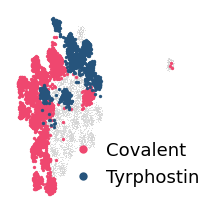

In [58]:
# Highlight Covalent and Tyrphostin drugs on the UMAP, rest in gray
umap_coords = sub.obsm['X_umap']
is_covalent = (sub.obs['reversible'] == 'Covalent').values
is_tyrphostin = (sub.obs['class_broad'] == 'tyrphostin').values
is_other = ~(is_covalent | is_tyrphostin)

fig, ax = plt.subplots(figsize=(2, 2))

# background cells: small, light, drawn first
ax.scatter(
    umap_coords[is_other, 0], umap_coords[is_other, 1],
    s=0.5, c='lightgray', linewidths=0, alpha=0.6, zorder=1,
)

# highlighted cells: larger, saturated, dark-outlined so they stay legible even shrunk down
ax.scatter(
    umap_coords[is_covalent, 0], umap_coords[is_covalent, 1],
    s=2, c='#ef476f', alpha=0.95, zorder=2, label='Covalent',
)
ax.scatter(
    umap_coords[is_tyrphostin, 0], umap_coords[is_tyrphostin, 1],
    s=2, c='#26547c', alpha=0.95, zorder=3, label='Tyrphostin',
)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='#ef476f', markeredgewidth=0, markersize=6, label='Covalent'),
    Line2D([0], [0], marker='o', linestyle='none', markerfacecolor='#26547c', markeredgewidth=0, markersize=6, label='Tyrphostin'),
]
ax.legend(
    handles=legend_handles, loc='lower right', bbox_to_anchor=(1.2, 0.0),
    frameon=False, fontsize=13, handletextpad=0.3,
)

plt.tight_layout(pad=0.2)
for ext in ('svg', 'png', 'pdf'):
    plt.savefig(
        os.path.join(figure_dir, f'{pert_type}_{concentration}_covalent_tyrphostin_highlight.{ext}'),
        dpi=300, bbox_inches='tight',
    )
plt.show()


### Enrichment of drug classes in Sherlock perturbation groups (Fisher's exact test)

In [59]:
overview_cols = ['class_broad',  'reversible']

In [60]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import itertools

# ── build per-drug annotation table ──────────────────────────────────────────
# use one row per drug (not per cell) to avoid pseudo-replication
drug_obs = (
    sub.obs[['drug', 'pert_group'] + overview_cols]
    .drop_duplicates('drug')
    .dropna(subset=['pert_group'])
    .copy()
)
drug_obs['pert_group'] = drug_obs['pert_group'].astype(str)

groups = sorted(drug_obs['pert_group'].unique())
n_total = len(drug_obs)

rows = []
for col in overview_cols:
    cats = [c for c in drug_obs[col].dropna().unique() if c != 'Unknown']
    for cat in cats:
        in_cat = drug_obs[col] == cat
        for grp in groups:
            in_grp = drug_obs['pert_group'] == grp
            a = (in_cat &  in_grp).sum()   # in cat AND in group
            b = (in_cat & ~in_grp).sum()   # in cat, NOT in group
            c = (~in_cat &  in_grp).sum()  # NOT in cat, in group
            d = (~in_cat & ~in_grp).sum()  # neither
            _, p = fisher_exact([[a, b], [c, d]], alternative='greater')
            rows.append({'column': col, 'category': cat, 'group': grp,
                         'n_overlap': a, 'p_value': p})

df_enrich = pd.DataFrame(rows)

# FDR correction (Benjamini-Hochberg) across all tests
_, df_enrich['padj'], _, _ = multipletests(df_enrich['p_value'], method='fdr_bh')
df_enrich['neg_log10_padj'] = -np.log10(df_enrich['padj'].clip(1e-10))

sig = df_enrich[df_enrich['padj'] < 0.05].sort_values('padj')
print(f"Significant enrichments (FDR < 0.05): {len(sig)}")
sig


Significant enrichments (FDR < 0.05): 2


,column,category,group,n_overlap,p_value,padj,neg_log10_padj
59,reversible,Covalent,4,11,0.000120,0.008156,2.088543
12,class_broad,tyrphostin,1,5,0.001184,0.040244,1.395299


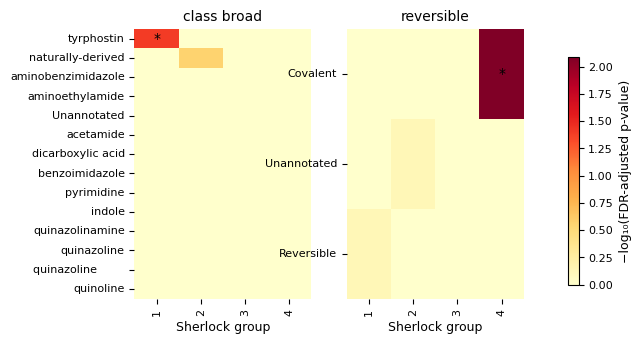

In [61]:
# ── heatmap: one panel per annotation column ─────────────────────────────────
# Color = -log10(FDR-adjusted p-value): brighter = more significant enrichment
# * marks FDR < 0.05

import matplotlib.cm as cm
import matplotlib.colors as mcolors

vmax = df_enrich['neg_log10_padj'].replace([np.inf], 10).max()
norm = mcolors.Normalize(vmin=0, vmax=vmax)
cmap = plt.get_cmap('YlOrRd')

fig, axes = plt.subplots(1, len(overview_cols),
                         figsize=(2.8 * len(overview_cols), 3.5))

for ax, col in zip(axes, overview_cols):
    pivot = (
        df_enrich[df_enrich['column'] == col]
        .pivot(index='category', columns='group', values='neg_log10_padj')
        .fillna(0)
    )
    pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]

    sns.heatmap(
        pivot,
        ax=ax,
        cmap='YlOrRd',
        vmin=0,
        vmax=vmax,
        linewidths=0,
        cbar=False,
        xticklabels=True,
        yticklabels=True,
    )

    # star significant cells
    for r, row_cat in enumerate(pivot.index):
        for c, grp in enumerate(pivot.columns):
            if pivot.loc[row_cat, grp] > 1.3:
                ax.text(c + 0.5, r + 0.5, '*', ha='center', va='center',
                        fontsize=10, color='black')

    ax.set_title(col.replace('_', ' '), fontsize=10)
    ax.set_xlabel('Sherlock group', fontsize=9)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8, rotation=90)
    ax.tick_params(axis='y', labelsize=8)

# shared colorbar on the right
fig.subplots_adjust(right=0.82)
cbar_ax = fig.add_axes([0.90, 0.15, 0.018, 0.65])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('−log₁₀(FDR-adjusted p-value)', fontsize=9)
cbar.ax.tick_params(labelsize=8)
# mark the FDR < 0.05 threshold line
# cbar.ax.axhline(y=1.3, color='black', linewidth=1.2, linestyle='--')
# cbar.ax.text(2.8, 1.3, 'FDR=0.05', va='center', fontsize=7, color='black',
#              transform=cbar.ax.get_yaxis_transform())

for ext in ('svg', 'png', 'pdf'):
    plt.savefig(
        os.path.join(figure_dir,
                     f'{pert_type}_{concentration}_enrichment_heatmap.{ext}'),
        dpi=300, bbox_inches='tight'
    )
plt.show()


In [62]:
sc.pp.normalize_total(sub)
sc.pp.log1p(sub)
sc.pp.pca(sub, random_state=0)

sc.pp.neighbors(sub, random_state=0)
sc.tl.umap(sub, random_state=0)

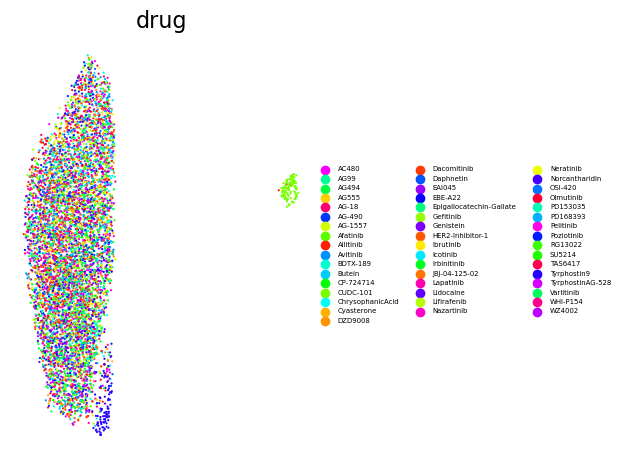

In [63]:
# Alternative: Save manually with more control
sc.pl.umap(
    sub,
    color='drug',
    title='drug',
    palette=palette,
    size=10,
    frameon=False,
    show=False,
    legend_fontsize=5,
)
plt.tight_layout()
plt.savefig(os.path.join(figure_dir,'umap_pathway_comparison_pert_presherlock.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir,'umap_pathway_comparison_pert_presherlock.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir,'umap_pathway_comparison_pert_presherlock.svg'), dpi=300, bbox_inches='tight')
plt.show()

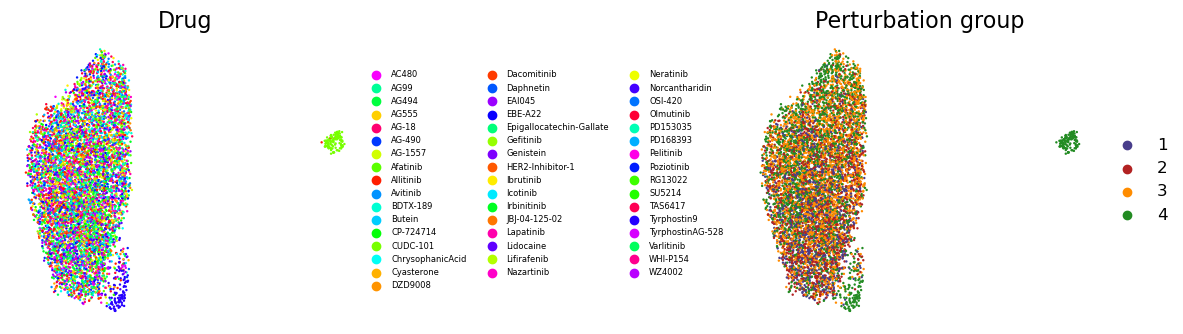

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

sc.pl.umap(
    sub,
    color='drug',
    title='Drug',
    palette=palette,
    size=12,
    frameon=False,
    ax=axes[0],
    show=False,
    legend_fontsize=6,
)

sc.pl.umap(sub, color='pert_group', title='Perturbation group', 
           palette=new_colormap, size=12, frameon=False, ax=axes[1], show=False)

plt.tight_layout()
plt.savefig(os.path.join(figure_dir, f"{pert_type}_{concentration}_sherlock_zspace_presherlock.svg"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{pert_type}_{concentration}_sherlock_zspace_presherlock.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(figure_dir, f"{pert_type}_{concentration}_sherlock_zspace_presherlock.pdf"), dpi=300, bbox_inches='tight')
plt.show()

# End here